In [1]:
# Import Libraries
import os
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from IPython.display import display
from google.colab import drive
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

In [2]:
# Enable and Confirm GPU Support
# XGboost must run a "dummy test" to confirm
try:
    xgb.train(
        {"device": "cuda"},
        xgb.DMatrix([[0]], label=[0]),
        num_boost_round=1
    )
    DEVICE = "cuda"
    print("GPU confirmed. XGBoost is using CUDA.")

except Exception as gpu_error:
    try:
        xgb.train(
            {"device": "cpu"},
            xgb.DMatrix([[0]], label=[0]),
            num_boost_round=1
        )
        DEVICE = "cpu"
        print(
            f"GPU support unavailable. [Reason: {gpu_error}]\n"
            f"Model has successfully defaulted to CPU usage instead."
        )

    except Exception as cpu_error:
        DEVICE = None
        print(
            f"GPU and CPU usage are both unavailable.\n"
            f"  GPU Reason: {gpu_error}\n"
            f"  CPU Reason: {cpu_error}\n\n"
            f"Troubleshooting suggestions:\n"
            f"  1. Verify XGBoost is installed correctly  : pip install xgboost\n"
            f"  2. Verify your CUDA drivers are up to date : https://developer.nvidia.com/cuda-downloads\n"
            f"  3. Confirm your Python environment is not corrupted\n"
            f"  4. Try reinstalling XGBoost                : pip install --force-reinstall xgboost"
        )

GPU confirmed. XGBoost is using CUDA.


In [3]:
# Define file path & Load TRAIN and VALIDATE Datasets
drive.mount('/content/drive', force_remount=True)
df = pd.read_csv('/content/drive/MyDrive/xg-ids/5class/datasets/5class_TRAIN.txt')
df_val = pd.read_csv('/content/drive/MyDrive/xg-ids/5class/datasets/5class_VALIDATE.txt')

Mounted at /content/drive


In [4]:
# Experiment 4: Feature Subset recommended by Dr. Raouf (SHAP)
selected_features = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'logged_in', 'count', 'srv_count', 'same_srv_rate', 'diff_srv_rate',
    'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'dst_host_same_srv_rate', 'num_failed_logins', 'num_root',
    'root_shell', 'num_file_creations'
]

# Get all columns except the target
all_features = [col for col in df.columns if col != 'class']

# Determine which columns to drop (all columns not in selected features)
cols_to_drop = [col for col in all_features if col not in selected_features]

if cols_to_drop:
    df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    df_val.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    print(f"Using professor-recommended feature subset with {len(selected_features)} features")
    print(f"Dropped {len(cols_to_drop)} features: {cols_to_drop}")
    print(f"  Train shape   : {df.shape}")
    print(f"  Validate shape: {df_val.shape}")
else:
    print("All features retained.")

# Keep zv_train and zv_val defined so downstream code doesn't break
zv_train = []
zv_val   = []

Using professor-recommended feature subset with 20 features
Dropped 21 features: ['land', 'wrong_fragment', 'urgent', 'hot', 'num_compromised', 'su_attempted', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']
  Train shape   : (39928, 21)
  Validate shape: (12663, 21)


In [5]:
# XGBOOST CONFIGURATIONS
config = {

    #GLOBAL & GENERAL CONFIGURATIONS
    "verbosity"            : 1,                # 0 (silent), 1 (warning), 2 (info), 3 (debug)
    "booster"              : "gbtree",         # DEFAULT: gbtree --  Options: "gbtree" (Standard Gradient Boosting), "gblinear" (Linear Models), "dart" (Dropout Trees)
    "device"               : DEVICE,           # Options: "cuda", "cpu" - Specified in cell 2
    "validate_parameters"  : True,          # Use with Python. XGBoost validates input parameters and warns if any are unused or unrecognized.
    "disable_default_eval_metric" : False,    # XGBoost supports variety of "eval_metric" options with defaults and customizability.

    # TREE BOOSTER PARAMETERS
    "eta"                  : 0.05,              # DEFAULT: 0.3 - Alias for "learning_rate". Controls step size shrinkage to prevent overfitting.
    "gamma"                : 2,                # DEFAULT: 0 - Minimum loss reduction required to make a split. Higher values = more conservative models.
    "max_depth"            : 8,                # DEFAULT: 6 - Maximum depth of a tree. Increasing may capture more complex patterns BUT may overfit.
    "min_child_weight"     : 5,                # DEFAULT: 1 - [Options: 0,∞] Minimum sum of instance weight (hessian) needed in a child. Higher values prevent overfitting.
                                               # Relevant for U2R and R2L (Low # might cause overfitting)
    "max_delta_step"       : 1,                # DEFAULT: 0 - Maximum delta step allowed. 0 = no constraints. May help with logistic regressionin imbalanced datasets.
    "subsample"           : 0.8,                # DEFAULT: 1 - [Range: 0,1]Randomly subsample dataset prior to growing tree. May prevent overfitting. Occurs once per boosting iteration.
    "sampling_method"      : "uniform",        # DEFAULT: uniform - Options: "uniform" (Random sampling), "gradient_based" (Gradient-based sampling)
    "lambda"               : 3,                # DEFAULT: 1 - [Options: 0,∞] (Alias: reg_lambda) L2 regularization term on weights. Increase = more conservative models.
    "alpha"                : 1,                # DEFAULT: 0 - [Options: 0,∞] (Alias: reg_alpha) L1 regularization term on weights. Increase = more conservative models.
    "tree_method"         : "hist",            # DEFAULT: auto - Options: "auto" (same as "hist"), "exact" (Exact greedy algorithm), "approx" (Approximate algorithm using quantile sketching), "hist" (Histogram-based algorithm)
    "process_type"        : "default",         # DEFAULT: default - Options: "default" (Standard training), "update" (Continue training from existing model)
    "objective"            : "multi:softprob", # Many other options (see documentation), but "multi:softmax" is likely the most promising alternative.
    # "base_score" -- Automatically estimated by XGBoost for multi:softprob — no manual override needed
    "eval_metric" : ["mlogloss", "merror"], # Defaults to "mlogloss" for multi:softprob, but can be overridden with other options. See documentation.
    "seed" : 0, # RNG to ensure reproducibility of results across different runs/environments.
    "enable_categorical" : True, # Avoids using One-Hot Encoding and allows XGBoost to natively handle categorical features.
    "num_class"            : 5,  # Required for multiclass classification with "multi:softprob" objective. Specifies number of classes in the dataset.
    "n_estimators"         : 500,              # DEFAULT: 100 - Number of boosting rounds (trees).
    "early_stopping_rounds": 20,        # DEFAULT: None -- Early stopping if no imporvement (eval metric) for specified rounds.
    # Prototyping
    "prototyping"          : False,
    "prototyping_frac"     : 0.2,              # fraction of data to use when prototyping
    "prototyping_stratified": True,            # ensure all classes are represented
}

In [6]:
# TRAIN & VALIDATE Dataset: Encode datasets + separate Features and Targets
# Cast categorical feature columns to category dtype for XGBoost native handling
categorical_cols = ['protocol_type', 'service', 'flag']
for col in categorical_cols:
    df[col]     = df[col].astype('category')
    df_val[col] = df_val[col].astype('category')

# Encode target class labels to integers (required by XGBoost)
le = LabelEncoder()
df['class']     = le.fit_transform(df['class'])
df_val['class'] = le.transform(df_val['class'])

# Print class encoding map
class_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Class encoding map:")
for cls, idx in class_map.items():
    print(f"  {cls} → {idx}")

# Separate features and target
X_train = df.drop(columns=['class'])
y_train = df['class']

X_val   = df_val.drop(columns=['class'])
y_val   = df_val['class']

Class encoding map:
  DoS → 0
  Normal → 1
  Probe → 2
  R2L → 3
  U2R → 4


In [7]:
# Prototyping Configurations
if config["prototyping"]:
    X_train, _, y_train, _ = train_test_split(
        X_train, y_train,
        train_size=config["prototyping_frac"],
        stratify=y_train if config["prototyping_stratified"] else None,
        random_state=config["seed"]
    )
    X_val, _, y_val, _ = train_test_split(
        X_val, y_val,
        train_size=config["prototyping_frac"],
        stratify=y_val if config["prototyping_stratified"] else None,
        random_state=config["seed"]
    )
    print(f"Prototyping mode: using {len(X_train)} train instances and {len(X_val)} val instances ({config['prototyping_frac']*100:.0f}% of each dataset)")
else:
    print(f"Full training mode: using {len(X_train)} train instances and {len(X_val)} val instances")

Full training mode: using 39928 train instances and 12663 val instances


In [8]:
model = xgb.XGBClassifier(
    verbosity          = config["verbosity"],
    booster            = config["booster"],
    device             = config["device"],
    validate_parameters= config["validate_parameters"],
    eta                = config["eta"],
    gamma              = config["gamma"],
    max_depth          = config["max_depth"],
    min_child_weight   = config["min_child_weight"],
    max_delta_step     = config["max_delta_step"],
    subsample          = config["subsample"],
    sampling_method    = config["sampling_method"],
    reg_lambda         = config["lambda"],
    reg_alpha          = config["alpha"],
    tree_method        = config["tree_method"],
    process_type       = config["process_type"],
    objective          = config["objective"],
    eval_metric        = config["eval_metric"],
    seed               = config["seed"],
    enable_categorical = config["enable_categorical"],
    num_class          = config["num_class"],
    n_estimators       = config["n_estimators"],
    early_stopping_rounds = config["early_stopping_rounds"],
)

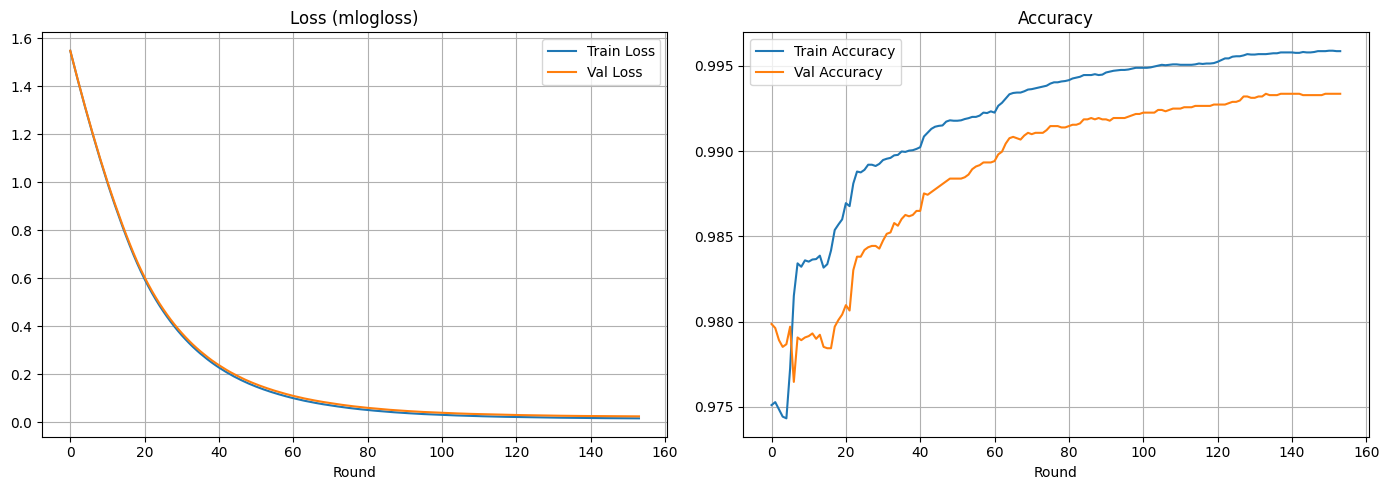

In [9]:
evals_result = {}

model.fit(
    X_train, y_train.to_numpy(),
    sample_weight=compute_sample_weight('balanced', y_train),
    eval_set=[(X_train, y_train.to_numpy()), (X_val, y_val.to_numpy())],
    verbose=False
)

# Plot after training
evals_result = model.evals_result()
train_loss = evals_result["validation_0"]["mlogloss"]
val_loss   = evals_result["validation_1"]["mlogloss"]
train_acc  = [1 - e for e in evals_result["validation_0"]["merror"]]
val_acc    = [1 - e for e in evals_result["validation_1"]["merror"]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_loss, label="Train Loss")
ax1.plot(val_loss,   label="Val Loss")
ax1.set_title("Loss (mlogloss)")
ax1.set_xlabel("Round")
ax1.legend()
ax1.grid(True)

ax2.plot(train_acc, label="Train Accuracy")
ax2.plot(val_acc,   label="Val Accuracy")
ax2.set_title("Accuracy")
ax2.set_xlabel("Round")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

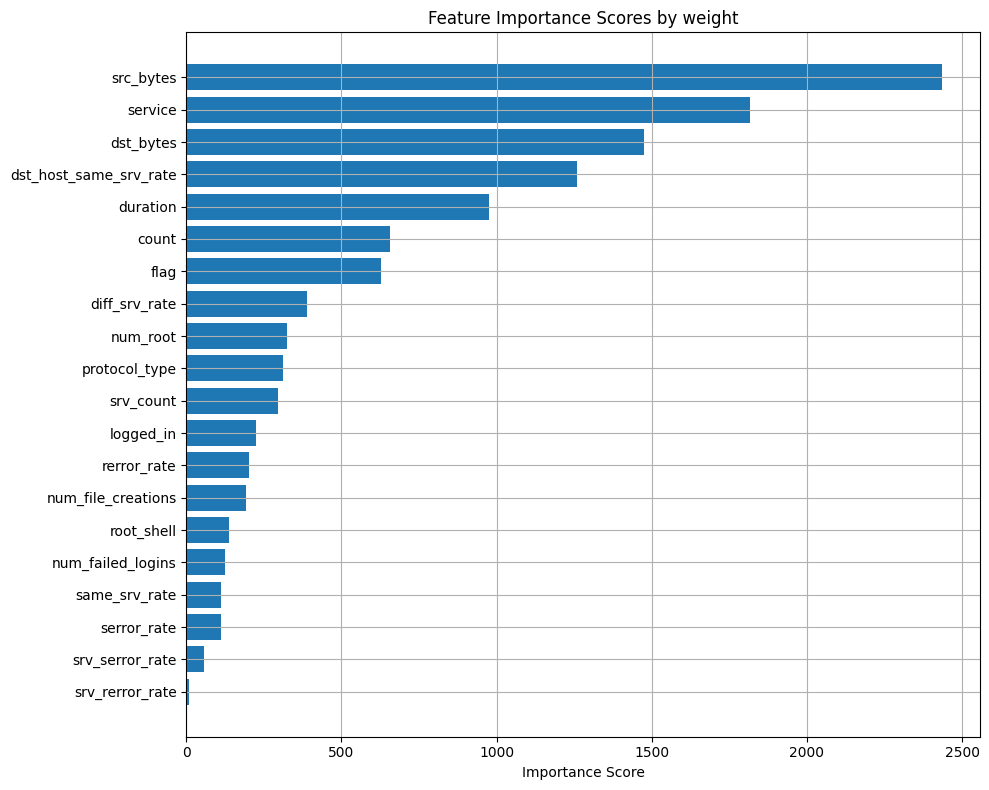


 Feature Importance Scores (weight):
               feature  importance
             src_bytes      2435.0
               service      1818.0
             dst_bytes      1476.0
dst_host_same_srv_rate      1258.0
              duration       976.0
                 count       657.0
                  flag       627.0
         diff_srv_rate       389.0
              num_root       323.0
         protocol_type       310.0
             srv_count       296.0
             logged_in       225.0
           rerror_rate       202.0
    num_file_creations       193.0
            root_shell       139.0
     num_failed_logins       123.0
         same_srv_rate       113.0
           serror_rate       111.0
       srv_serror_rate        57.0
       srv_rerror_rate         7.0


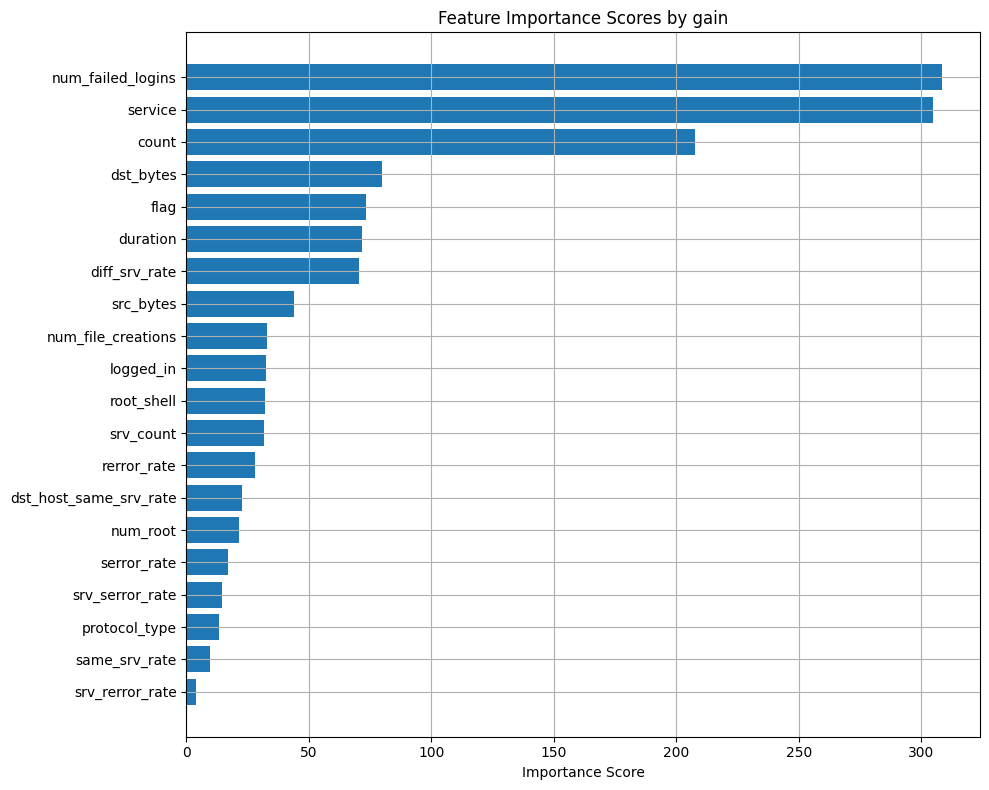


 Feature Importance Scores (gain):
               feature  importance
     num_failed_logins  308.520477
               service  304.585846
                 count  207.650894
             dst_bytes   79.793968
                  flag   73.511810
              duration   71.840027
         diff_srv_rate   70.407791
             src_bytes   43.776550
    num_file_creations   33.072239
             logged_in   32.530689
            root_shell   31.976822
             srv_count   31.504227
           rerror_rate   28.002552
dst_host_same_srv_rate   22.749403
              num_root   21.363564
           serror_rate   17.164251
       srv_serror_rate   14.729180
         protocol_type   13.486478
         same_srv_rate    9.523244
       srv_rerror_rate    4.061382


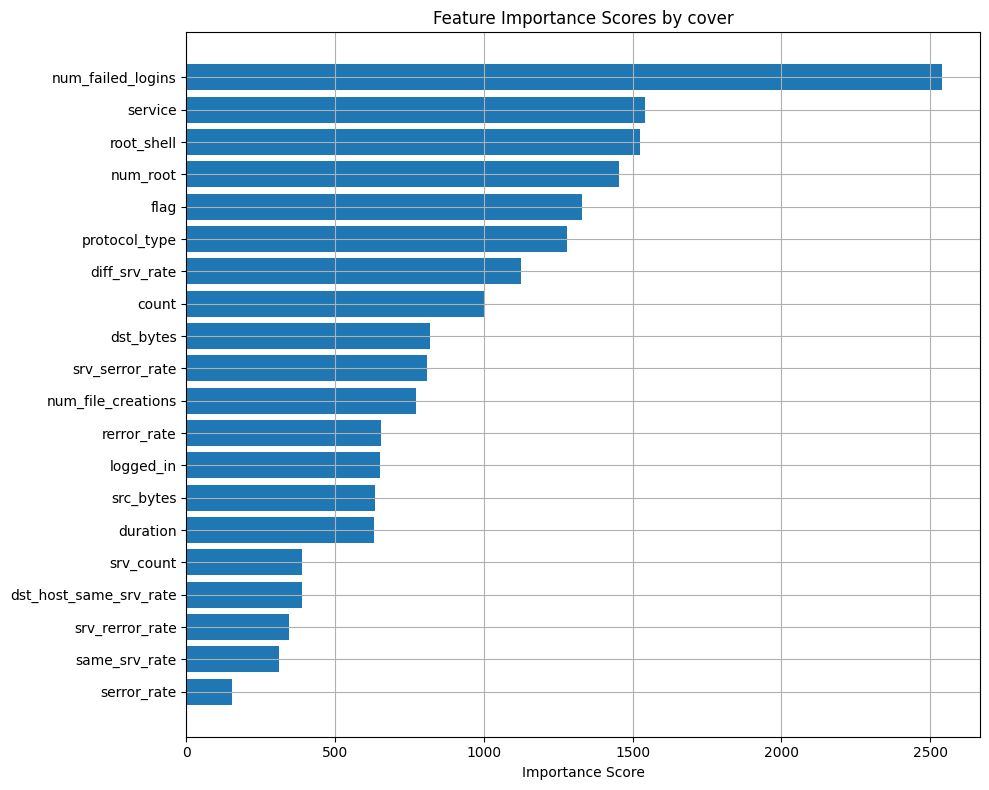


 Feature Importance Scores (cover):
               feature  importance
     num_failed_logins 2540.842041
               service 1541.889893
            root_shell 1523.553467
              num_root 1453.600098
                  flag 1328.987427
         protocol_type 1280.117310
         diff_srv_rate 1126.607300
                 count 1000.793579
             dst_bytes  819.933350
       srv_serror_rate  810.221924
    num_file_creations  772.441162
           rerror_rate  655.390564
             logged_in  652.618164
             src_bytes  634.686829
              duration  631.086243
             srv_count  390.207825
dst_host_same_srv_rate  389.671417
       srv_rerror_rate  345.399597
         same_srv_rate  312.708618
           serror_rate  153.161240


In [10]:
# Feature Importance
importance_types = ['weight', 'gain', 'cover']

for imp_type in importance_types:
    scores = model.get_booster().get_score(importance_type=imp_type)
    importance_df = pd.DataFrame({
        'feature': X_train.columns.tolist(),
        'importance': [scores.get(f, 0.0) for f in X_train.columns]
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    top = importance_df.head(20)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(top['feature'][::-1], top['importance'][::-1])
    ax.set_xlabel('Importance Score')
    ax.set_title(f'Feature Importance Scores by {imp_type}')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"\n Feature Importance Scores ({imp_type}):")
    print(importance_df.head(43).to_string(index=False))

In [11]:
# Load in Test Dataset, Encode it, and separate features and target
# Load test set
df_test = pd.read_csv('/content/drive/MyDrive/xg-ids/5class/datasets/5class_TEST.txt')

# Drop the same features that were dropped from train/val
if cols_to_drop:
    df_test.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    print(f"Dropped {len(cols_to_drop)} features from test set.")

# Cast categorical feature columns to category dtype
for col in categorical_cols:
    df_test[col] = df_test[col].astype('category')

# Encode target using the same LabelEncoder fitted on train set
df_test['class'] = le.transform(df_test['class'])

# Separate features and target
X_test = df_test.drop(columns=['class'])
y_test = df_test['class']

print(f"Test set loaded: {len(df_test)} instances")

Dropped 21 features from test set.
Test set loaded: 22544 instances


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [19:40:08] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Accuracy          : 0.8560
F1 (macro)        : 0.7088
F1 (weighted)     : 0.8483
Precision (weighted): 0.8707
Recall (weighted) : 0.8560

Per-class F1:
  DoS: 0.9075
  Normal: 0.8714
  Probe: 0.8460
  R2L: 0.6506
  U2R: 0.2682

Classification Report:
              precision    recall  f1-score   support

         DoS       0.96      0.86      0.91      7458
      Normal       0.79      0.97      0.87      9711
       Probe       0.82      0.87      0.85      2421
         R2L       0.96      0.49      0.65      2754
         U2R       0.57      0.17      0.27       200

    accuracy                           0.86     22544
   macro avg       0.82      0.67      0.71     22544
weighted avg       0.87      0.86      0.85     22544



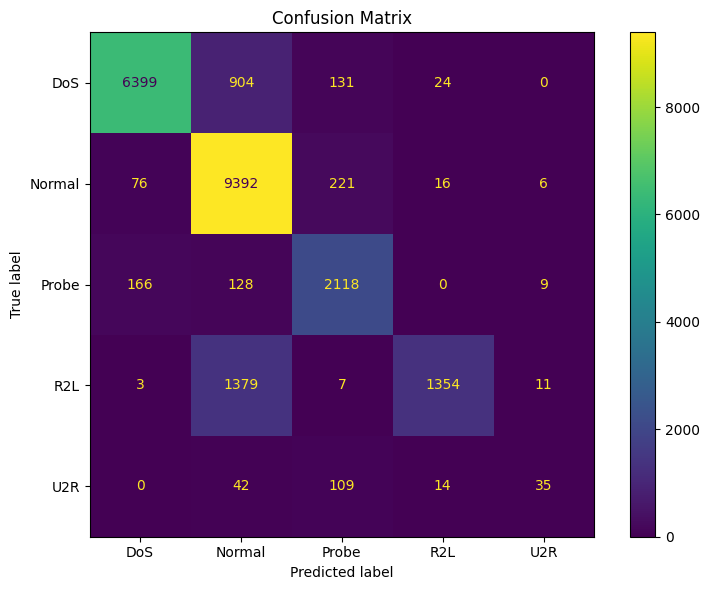

In [12]:
y_pred = model.predict(X_test)


accuracy  = accuracy_score(y_test, y_pred)
f1_macro  = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')

print(f"Accuracy          : {accuracy:.4f}")
print(f"F1 (macro)        : {f1_macro:.4f}")
print(f"F1 (weighted)     : {f1_weighted:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted) : {recall:.4f}")

# F1-Score
f1_per_class = f1_score(y_test, y_pred, average=None)
print(f"\nPer-class F1:")
for cls, score in zip(le.classes_, f1_per_class):
    print(f"  {cls}: {score:.4f}")

# Classification
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=True)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()